# 난임 임신 성공 확률 예측

기존 최종본을 바탕으로 다음을 추가/수정했습니다.

- Funnel 파생 피처 추가
- 과거 실패 횟수 피처 추가
- 나이 × 동결 × 이식일 등 상호작용 추가
- 기존 D 피처 세트와 개선 E 피처 세트 비교
- LightGBM/XGBoost 범주 인코딩을 **각 fold train에서만 fit**
- validation/test unseen category는 `-1`
- Optuna 내부 CV에서도 fold별 인코딩
- 최종 7-Fold에서 multi-seed ensemble
- OOF Logistic Stacking 추가
- 같은 OOF에서 가중치를 과도하게 탐색한 뒤 최고 점수를 최종 성능처럼 보고하는 과정 제거

> 중요한 구분  
> A/B/C/D/E 중 최고 세트를 고르는 CV는 개발용 모델 선택 점수입니다.  
> 여러 후보 중 최고를 선택했기 때문에 완전히 독립적인 최종 성능 추정치는 아닙니다.  
> 그러나 피처 값 생성이나 fold 인코딩 과정에서 validation/test의 타깃 정보는 사용하지 않습니다.


In [ ]:
# Colab에서 최초 1회만 설치됩니다.
import importlib.util, subprocess, sys

required = {
    "lightgbm": "lightgbm", "xgboost": "xgboost", "catboost": "catboost",
    "shap": "shap", "optuna": "optuna", "koreanize_matplotlib": "koreanize-matplotlib"
}
missing = [pip for module, pip in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("준비 완료")


준비 완료


In [ ]:
import warnings, os, gc, optuna
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
TARGET = "임신 성공 여부"
ID_COL = "ID"
FEATURE_SPLITS = 5
TUNE_SPLITS = 3
FINAL_SPLITS = 7
TUNE_TRIALS = 30
USE_GPU = os.system("nvidia-smi > /dev/null 2>&1") == 0

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 150)
print("GPU 사용 가능:", USE_GPU)


GPU 사용 가능: True


## 1. 데이터 로드

세 CSV를 `/content`에 올렸다고 가정합니다.  
파일이 없으면 바로 어떤 파일이 없는지 알려주도록 했습니다.


In [ ]:
DATA_DIR = Path("/content")

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SUB_PATH = DATA_DIR / "sample_submission.csv"

for p in [TRAIN_PATH, TEST_PATH, SUB_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"{p.name} 파일이 없습니다. Colab /content에 업로드해주세요.")

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
submission = pd.read_csv(SUB_PATH)

print("train:", train.shape)
print("test:", test.shape)
print("submission:", submission.shape)
print("\n타겟 비율:")
display(train[TARGET].value_counts(normalize=True).rename("비율"))


train: (256351, 69)
test: (90067, 68)
submission: (90067, 2)

타겟 비율:


,비율
임신 성공 여부,
0,0.741651
1,0.258349


## 2. 최소 안전 전처리

여기서는 원본의 의미를 가능한 유지합니다.

- ID는 모델 입력에서 제외
- 상수 컬럼은 자동 제거
- 범주형 결측은 `Missing`
- 숫자형 결측은 트리 모델이 직접 처리
- 임의 평균 대체로 구조적 결측 정보를 지우지 않음


In [ ]:
# train/test 공통 상수 컬럼만 제거
feature_cols = [c for c in test.columns if c != ID_COL]
constant_cols = [c for c in feature_cols if train[c].nunique(dropna=False) <= 1]

print("상수 컬럼:", constant_cols)

if constant_cols:
    train = train.drop(columns=constant_cols)
    test = test.drop(columns=constant_cols)

y = train[TARGET].copy()
base_train = train.drop(columns=[TARGET, ID_COL]).copy()
base_test = test.drop(columns=[ID_COL]).copy()

print("기본 피처 수:", base_train.shape[1])


상수 컬럼: ['불임 원인 - 여성 요인']
기본 피처 수: 66


## 3. 파생변수 생성

`확인요망.ipynb`에서 만든 변수 중 안전하게 사용할 수 있는 핵심 변수들을 함수화했습니다.  
특히 **배아 생성/저장 비율, 과거 시술 이력, 미세주입 비율, 동결 여부×이식 경과일**을 포함합니다.


In [ ]:
import warnings, os, gc, optuna
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
TARGET = "임신 성공 여부"
ID_COL = "ID"
FEATURE_SPLITS = 5
TUNE_SPLITS = 3
FINAL_SPLITS = 7
TUNE_TRIALS = 30
USE_GPU = os.system("nvidia-smi > /dev/null 2>&1") == 0

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 150)
print("GPU 사용 가능:", USE_GPU)

COUNT_MAP = {
    "0회": 0, "1회": 1, "2회": 2, "3회": 3,
    "4회": 4, "5회": 5, "6회 이상": 6,
}

COUNT_COLS = [
    "총 시술 횟수", "총 임신 횟수", "총 출산 횟수",
    "IVF 시술 횟수", "IVF 임신 횟수", "IVF 출산 횟수",
    "DI 시술 횟수", "DI 임신 횟수",
]

DETAIL_CAUSE_COLS = [
    "불임 원인 - 난관 질환",
    "불임 원인 - 남성 요인",
    "불임 원인 - 배란 장애",
    "불임 원인 - 여성 요인",
    "불임 원인 - 자궁경부 문제",
    "불임 원인 - 자궁내막증",
    "불임 원인 - 정자 농도",
    "불임 원인 - 정자 면역학적 요인",
    "불임 원인 - 정자 운동성",
    "불임 원인 - 정자 형태",
]

def safe_divide(numerator, denominator):
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce")
    return numerator.div(denominator.where(denominator > 0))

def combine_categories(df, columns):
    return (
        df[columns]
        .fillna("Missing")
        .astype(str)
        .agg("_".join, axis=1)
    )

def make_features(df):
    out = df.copy()

    # 1) 구조적 결측 / 해동 관련
    if "해동 난자 수" in out.columns:
        out["난자 해동 여부"] = (out["해동 난자 수"].fillna(0) > 0).astype("int8")
    else:
        out["난자 해동 여부"] = np.nan

    if "해동된 배아 수" in out.columns:
        out["배아 해동 여부"] = (out["해동된 배아 수"].fillna(0) > 0).astype("int8")
    else:
        out["배아 해동 여부"] = np.nan

    if "난자 해동 경과일" in out.columns:
        out["난자해동경과일_존재"] = out["난자 해동 경과일"].notna().astype("int8")
    else:
        out["난자해동경과일_존재"] = np.nan

    if "배아 해동 경과일" in out.columns:
        out["배아해동경과일_존재"] = out["배아 해동 경과일"].notna().astype("int8")
    else:
        out["배아해동경과일_존재"] = np.nan

    # 2) 배아 생성/저장/이식 과정
    if "총 생성 배아 수" in out.columns and "혼합된 난자 수" in out.columns:
        out["배아 생성률"] = safe_divide(out["총 생성 배아 수"], out["혼합된 난자 수"])
    else:
        out["배아 생성률"] = np.nan

    if "저장된 배아 수" in out.columns and "총 생성 배아 수" in out.columns:
        out["배아 저장률"] = safe_divide(out["저장된 배아 수"], out["총 생성 배아 수"])
    else:
        out["배아 저장률"] = np.nan

    if "총 생성 배아 수" in out.columns and "이식된 배아 수" in out.columns:
        out["생성배아_이식차이"] = out["총 생성 배아 수"] - out["이식된 배아 수"]
    else:
        out["생성배아_이식차이"] = np.nan

    if "총 생성 배아 수" in out.columns and "이식된 배아 수" in out.columns and "저장된 배아 수" in out.columns:
        out["생성배아_이식저장잔여"] = (
            out["총 생성 배아 수"]
            - out["이식된 배아 수"].fillna(0)
            - out["저장된 배아 수"].fillna(0)
        )
    else:
        out["생성배아_이식저장잔여"] = np.nan

    if "혼합된 난자 수" in out.columns:
        out["신규 배아 생성 여부"] = (out["혼합된 난자 수"].fillna(0) > 0).astype("int8")
    else:
        out["신규 배아 생성 여부"] = np.nan

    if "이식된 배아 수" in out.columns:
        out["배아 이식 여부"] = (out["이식된 배아 수"].fillna(0) > 0).astype("int8")
    else:
        out["배아 이식 여부"] = np.nan

    has_total_generated = "총 생성 배아 수" in out.columns
    has_thawed_embryo = "해동된 배아 수" in out.columns

    if has_total_generated and has_thawed_embryo:
        out["배아 공급 유형"] = np.select(
            [
                (out["총 생성 배아 수"].fillna(0) > 0) & (out["해동된 배아 수"].fillna(0) == 0),
                (out["총 생성 배아 수"].fillna(0) == 0) & (out["해동된 배아 수"].fillna(0) > 0),
                (out["총 생성 배아 수"].fillna(0) > 0) & (out["해동된 배아 수"].fillna(0) > 0),
                (out["총 생성 배아 수"].fillna(0) == 0) & (out["해동된 배아 수"].fillna(0) == 0),
            ],
            ["신규 생성만", "해동 배아만", "신규+해동", "둘 다 없음"],
            default="기타"
        )
    else:
        out["배아 공급 유형"] = "기타_미확인"

    # 3) 과거 시술/임신/출산
    for col in COUNT_COLS:
        if col in out.columns:
            out[f"{col}_num"] = out[col].map(COUNT_MAP)
            out[f"{col}_6plus"] = (out[col] == "6회 이상").astype("int8")
        else:
            out[f"{col}_num"] = np.nan
            out[f"{col}_6plus"] = np.nan

    if "총 시술 횟수_num" in out.columns:
        out["과거 시술 경험 여부"] = (out["총 시술 횟수_num"].fillna(0) > 0).astype("int8")
    else:
        out["과거 시술 경험 여부"] = np.nan

    if "DI 시술 횟수_num" in out.columns:
        out["DI 경험 여부"] = (out["DI 시술 횟수_num"].fillna(0) > 0).astype("int8")
    else:
        out["DI 경험 여부"] = np.nan

    if "총 임신 횟수_num" in out.columns and "총 시술 횟수_num" in out.columns:
        out["과거 임신률"] = safe_divide(out["총 임신 횟수_num"], out["총 시술 횟수_num"])
    else:
        out["과거 임신률"] = np.nan

    if "총 출산 횟수_num" in out.columns and "총 임신 횟수_num" in out.columns:
        out["과거 출산률"] = safe_divide(out["총 출산 횟수_num"], out["총 임신 횟수_num"])
    else:
        out["과거 출산률"] = np.nan

    if "IVF 임신 횟수_num" in out.columns and "IVF 시술 횟수_num" in out.columns:
        out["IVF 과거 임신률"] = safe_divide(out["IVF 임신 횟수_num"], out["IVF 시술 횟수_num"])
    else:
        out["IVF 과거 임신률"] = np.nan

    if "IVF 출산 횟수_num" in out.columns and "IVF 임신 횟수_num" in out.columns:
        out["IVF 출산률"] = safe_divide(out["IVF 출산 횟수_num"], out["IVF 임신 횟수_num"])
    else:
        out["IVF 출산률"] = np.nan

    if "DI 임신 횟수_num" in out.columns and "DI 시술 횟수_num" in out.columns:
        out["DI 과거 임신률"] = safe_divide(out["DI 임신 횟수_num"], out["DI 시술 횟수_num"])
    else:
        out["DI 과거 임신률"] = np.nan

    valid_6plus_cols = [f"{c}_6plus" for c in COUNT_COLS if f"{c}_6plus" in out.columns]
    if valid_6plus_cols:
        out["과거비율_불확실"] = out[valid_6plus_cols].max(axis=1).astype("int8")
    else:
        out["과거비율_불확실"] = np.nan


    # 4) 미세주입(ICSI)
    if "미세주입된 난자 수" in out.columns:
        out["미세주입 여부"] = (out["미세주입된 난자 수"].fillna(0) > 0).astype("int8")
    else:
        out["미세주입 여부"] = np.nan

    if "미세주입된 난자 수" in out.columns and "혼합된 난자 수" in out.columns:
        out["미세주입 난자 비율"] = safe_divide(out["미세주입된 난자 수"], out["혼합된 난자 수"])
    else:
        out["미세주입 난자 비율"] = np.nan

    if "미세주입에서 생성된 배아 수" in out.columns and "미세주입된 난자 수" in out.columns:
        out["미세주입 배아 생성률"] = safe_divide(
            out["미세주입에서 생성된 배아 수"], out["미세주입된 난자 수"]
        )
    else:
        out["미세주입 배아 생성률"] = np.nan

    if "미세주입에서 생성된 배아 수" in out.columns and "총 생성 배아 수" in out.columns:
        out["미세주입 생성배아 비중"] = safe_divide(
            out["미세주입에서 생성된 배아 수"], out["총 생성 배아 수"]
        )
    else:
        out["미세주입 생성배아 비중"] = np.nan

    if "미세주입 배아 이식 수" in out.columns and "미세주입에서 생성된 배아 수" in out.columns:
        out["미세주입 배아 이식률"] = safe_divide(
            out["미세주입 배아 이식 수"], out["미세주입에서 생성된 배아 수"]
        )
    else:
        out["미세주입 배아 이식률"] = np.nan

    if "미세주입 후 저장된 배아 수" in out.columns and "미세주입에서 생성된 배아 수" in out.columns:
        out["미세주입 배아 저장률"] = safe_divide(
            out["미세주입 후 저장된 배아 수"], out["미세주입에서 생성된 배아 수"]
        )
    else:
        out["미세주입 배아 저장률"] = np.nan

    # 5) 상호작용
    if "동결 배아 사용 여부" in out.columns and "배아 이식 경과일" in out.columns:
        out["동결여부_이식경과일"] = combine_categories(
            out, ["동결 배아 사용 여부", "배아 이식 경과일"]
        )
    else:
        out["동결여부_이식경과일"] = "Missing_Missing"

    if "시술 당시 나이" in out.columns and "난자 출처" in out.columns:
        out["나이_난자출처"] = combine_categories(out, ["시술 당시 나이", "난자 출처"])
    else:
        out["나이_난자출처"] = "Missing_Missing"

    if "배란 자극 여부" in out.columns and "배란 유도 유형" in out.columns:
        out["배란자극_유도유형"] = combine_categories(out, ["배란 자극 여부", "배란 유도 유형"])
    else:
        out["배란자극_유도유형"] = "Missing_Missing"

    if "난자 출처" in out.columns and "난자 기증자 나이" in out.columns:
        out["난자출처_기증자나이"] = combine_categories(out, ["난자 출처", "난자 기증자 나이"])
    else:
        out["난자출처_기증자나이"] = "Missing_Missing"

    has_fresh_embryo_use = "신선 배아 사용 여부" in out.columns
    has_frozen_embryo_use = "동결 배아 사용 여부" in out.columns

    if has_fresh_embryo_use and has_frozen_embryo_use:
        out["배아 사용 유형"] = np.select(
            [
                (out["신선 배아 사용 여부"] == 1) & (out["동결 배아 사용 여부"] == 0),
                (out["신선 배아 사용 여부"] == 0) & (out["동결 배아 사용 여부"] == 1),
                (out["신선 배아 사용 여부"] == 1) & (out["동결 배아 사용 여부"] == 1),
            ],
            ["신선", "동결", "신선+동결"],
            default="기타"
        )
    else:
        out["배아 사용 유형"] = "기타_미확인"

    # 6) 불임 원인 / 유전검사 통합
    usable_causes = [c for c in DETAIL_CAUSE_COLS if c in out.columns]
    if usable_causes:
        out["세부 불임 원인 개수"] = out[usable_causes].fillna(0).sum(axis=1)
    else:
        out["세부 불임 원인 개수"] = np.nan

    genetic_cols = [
        c for c in [
            "착상 전 유전 검사 사용 여부",
            "착상 전 유전 진단 사용 여부",
            "PGD 시술 여부",
            "PGS 시술 여부",
        ] if c in out.columns
    ]
    if genetic_cols:
        out["유전검사_사용여부"] = out[genetic_cols].eq(1).any(axis=1).astype("int8")
    else:
        out["유전검사_사용여부"] = np.nan

    # 7) 추가 효율·단계 변수: 분모가 0인 경우는 0이 아니라 NaN으로 유지
    if "수정된 난자 수" in out.columns and "혼합된 난자 수" in out.columns:
        out["수정 성공률"] = safe_divide(out["수정된 난자 수"], out["혼합된 난자 수"])
    else:
        out["수정 성공률"] = np.nan

    if "이식된 배아 수" in out.columns and "총 생성 배아 수" in out.columns:
        out["이식 활용률"] = safe_divide(out["이식된 배아 수"], out["총 생성 배아 수"])
    else:
        out["이식 활용률"] = np.nan

    if "수정된 난자 수" in out.columns and "수집된 신선 난자 수" in out.columns:
        out["양질 난자 수정률"] = safe_divide(out["수정된 난자 수"], out["수집된 신선 난자 수"])
    else:
        out["양질 난자 수정률"] = np.nan

    if "이식된 배아 수" in out.columns and "저장된 배아 수" in out.columns:
        out["사용가능 배아 수"] = out["이식된 배아 수"].fillna(0) + out["저장된 배아 수"].fillna(0)
    else:
        out["사용가능 배아 수"] = np.nan

    if "사용가능 배아 수" in out.columns and "총 생성 배아 수" in out.columns:
        out["사용가능 배아율"] = safe_divide(out["사용가능 배아 수"], out["총 생성 배아 수"])
    else:
        out["사용가능 배아율"] = np.nan

    if "시술 당시 나이" in out.columns and "배아 이식 경과일" in out.columns:
        out["나이_이식경과일"] = combine_categories(out, ["시술 당시 나이", "배아 이식 경과일"])
    else:
        out["나이_이식경과일"] = "Missing_Missing"

    if "시술 유형" in out.columns and "배아 사용 유형" in out.columns:
        out["시술유형_배아사용"] = combine_categories(out, ["시술 유형", "배아 사용 유형"])
    else:
        out["시술유형_배아사용"] = "Missing_Missing"



    # 8) v2 성능 개선 피처
    # 모든 변수는 "현재 행에 이미 존재하는 원본 정보"만 사용합니다.
    # 타깃 평균/성공률 집계, 전체 train 통계, test 통계는 사용하지 않습니다.

    # (a) 난자 -> 수정 -> 배아 -> 이식 funnel
    if "혼합된 난자 수" in out.columns and "수집된 신선 난자 수" in out.columns:
        out["난자 혼합률"] = safe_divide(
            out["혼합된 난자 수"], out["수집된 신선 난자 수"]
        )
    else:
        out["난자 혼합률"] = np.nan

    if "총 생성 배아 수" in out.columns and "수정된 난자 수" in out.columns:
        out["수정후 배아 생성률"] = safe_divide(
            out["총 생성 배아 수"], out["수정된 난자 수"]
        )
    else:
        out["수정후 배아 생성률"] = np.nan

    if "생성배아_이식저장잔여" in out.columns and "총 생성 배아 수" in out.columns:
        out["생성배아_잔여율"] = safe_divide(
            out["생성배아_이식저장잔여"], out["총 생성 배아 수"]
        )
    else:
        out["생성배아_잔여율"] = np.nan

    if "사용가능 배아 수" in out.columns:
        out["사용가능배아_존재"] = (
            out["사용가능 배아 수"].fillna(0) > 0
        ).astype("int8")
    else:
        out["사용가능배아_존재"] = np.nan

    # (b) 과거 실패 누적 정보
    if "총 시술 횟수_num" in out.columns and "총 임신 횟수_num" in out.columns:
        out["과거 임신 실패 횟수"] = (
            out["총 시술 횟수_num"] - out["총 임신 횟수_num"]
        ).clip(lower=0)
        out["반복시술_무임신"] = (
            (out["총 시술 횟수_num"].fillna(0) >= 3) &
            (out["총 임신 횟수_num"].fillna(0) == 0)
        ).astype("int8")
    else:
        out["과거 임신 실패 횟수"] = np.nan
        out["반복시술_무임신"] = np.nan

    if "IVF 시술 횟수_num" in out.columns and "IVF 임신 횟수_num" in out.columns:
        out["IVF 임신 실패 횟수"] = (
            out["IVF 시술 횟수_num"] - out["IVF 임신 횟수_num"]
        ).clip(lower=0)
    else:
        out["IVF 임신 실패 횟수"] = np.nan

    if "총 임신 횟수_num" in out.columns and "총 출산 횟수_num" in out.columns:
        out["임신후 출산 실패 횟수"] = (
            out["총 임신 횟수_num"] - out["총 출산 횟수_num"]
        ).clip(lower=0)
    else:
        out["임신후 출산 실패 횟수"] = np.nan

    # (c) 강한 상호작용 후보
    if all(c in out.columns for c in ["시술 당시 나이", "동결 배아 사용 여부", "배아 이식 경과일"]):
        out["나이_동결_이식일"] = combine_categories(
            out, ["시술 당시 나이", "동결 배아 사용 여부", "배아 이식 경과일"]
        )
    else:
        out["나이_동결_이식일"] = "Missing_Missing_Missing"

    if all(c in out.columns for c in ["시술 당시 나이", "배아 사용 유형", "배아 이식 경과일"]):
        out["나이_배아사용_이식일"] = combine_categories(
            out, ["시술 당시 나이", "배아 사용 유형", "배아 이식 경과일"]
        )
    else:
        out["나이_배아사용_이식일"] = "Missing_Missing_Missing"

    if all(c in out.columns for c in ["단일 배아 이식 여부", "시술 당시 나이"]):
        out["단일이식_나이"] = combine_categories(
            out, ["단일 배아 이식 여부", "시술 당시 나이"]
        )
    else:
        out["단일이식_나이"] = "Missing_Missing"

    if all(c in out.columns for c in ["단일 배아 이식 여부", "배아 사용 유형"]):
        out["단일이식_배아유형"] = combine_categories(
            out, ["단일 배아 이식 여부", "배아 사용 유형"]
        )
    else:
        out["단일이식_배아유형"] = "Missing_Missing"


    # 지나치게 큰 비율값이 나무 모델의 분할을 불안정하게 만들지 않도록 상한만 제한
    ratio_cols = [c for c in out.columns if ("률" in c or "비율" in c or "비중" in c)]
    for c in ratio_cols:
        if c in out.columns and pd.api.types.is_numeric_dtype(out[c]):
            out[c] = out[c].clip(lower=0, upper=3)

    return out

GPU 사용 가능: True


In [ ]:
fe_train = make_features(base_train)
fe_test = make_features(base_test)

new_features = [c for c in fe_train.columns if c not in base_train.columns]

print("생성된 파생변수 수:", len(new_features))
display(pd.DataFrame({"파생변수": new_features}))


생성된 파생변수 수: 67


,파생변수
0,난자 해동 여부
1,배아 해동 여부
2,난자해동경과일_존재
3,배아해동경과일_존재
4,배아 생성률
...,...
62,임신후 출산 실패 횟수
63,나이_동결_이식일
64,나이_배아사용_이식일
65,단일이식_나이


## 4. A/B/C/D/E 피처 세트 만들기

파생변수를 무조건 다 쓰지 않고 같은 CV 조건에서 비교합니다.

- **A:** 원본만
- **B:** 원본 + 수치/비율/상태 파생
- **C:** 원본 + 상호작용/통합 범주 파생
- **D:** 원본 + 모든 파생
- **E:** 원본 + 모든 파생 v2


In [ ]:

V2_INTERACTION_FEATURES = [
    "나이_동결_이식일",
    "나이_배아사용_이식일",
    "단일이식_나이",
    "단일이식_배아유형",
]

V2_NUMERIC_FEATURES = [
    "난자 혼합률",
    "수정후 배아 생성률",
    "생성배아_잔여율",
    "사용가능배아_존재",
    "과거 임신 실패 횟수",
    "반복시술_무임신",
    "IVF 임신 실패 횟수",
    "임신후 출산 실패 횟수",
]

V2_FEATURES = [
    c for c in (V2_INTERACTION_FEATURES + V2_NUMERIC_FEATURES)
    if c in fe_train.columns
]

INTERACTION_FEATURES = [
    "배아 공급 유형",
    "동결여부_이식경과일",
    "나이_난자출처",
    "배란자극_유도유형",
    "난자출처_기증자나이",
    "배아 사용 유형",
    "나이_이식경과일",
    "시술유형_배아사용",
]
INTERACTION_FEATURES = [c for c in INTERACTION_FEATURES if c in new_features]

# 기존 버전의 파생변수와 v2 신규 피처를 분리합니다.
OLD_NEW_FEATURES = [c for c in new_features if c not in V2_FEATURES]
OLD_INTERACTIONS = [c for c in INTERACTION_FEATURES if c in OLD_NEW_FEATURES]
OLD_NUMERIC_DERIVED = [c for c in OLD_NEW_FEATURES if c not in OLD_INTERACTIONS]

FEATURE_SETS = {
    "A_원본": list(base_train.columns),
    "B_원본+기존수치파생": list(base_train.columns) + OLD_NUMERIC_DERIVED,
    "C_원본+기존상호작용": list(base_train.columns) + OLD_INTERACTIONS,
    "D_기존전체파생": [c for c in fe_train.columns if c not in V2_FEATURES],
    "E_v2개선전체": list(fe_train.columns),
}

for name, cols in FEATURE_SETS.items():
    print(f"{name}: {len(cols)}개")

print("\n신규 v2 피처:")
for c in V2_FEATURES:
    print(" -", c)

print("""
주의:
- 이 A/B/C/D/E 비교는 '개발용 CV'입니다.
- 여러 피처 세트를 비교한 뒤 최고 세트를 선택하므로,
  최고 CV 점수를 완전히 독립적인 최종 일반화 성능으로 해석하면 안 됩니다.
- 다만 타깃을 이용해 피처 값을 만든 것은 아니므로 target leakage는 없습니다.
""")


A_원본: 66개
B_원본+기존수치파생: 113개
C_원본+기존상호작용: 74개
D_기존전체파생: 121개
E_v2개선전체: 133개

신규 v2 피처:
 - 나이_동결_이식일
 - 나이_배아사용_이식일
 - 단일이식_나이
 - 단일이식_배아유형
 - 난자 혼합률
 - 수정후 배아 생성률
 - 생성배아_잔여율
 - 사용가능배아_존재
 - 과거 임신 실패 횟수
 - 반복시술_무임신
 - IVF 임신 실패 횟수
 - 임신후 출산 실패 횟수

주의:
- 이 A/B/C/D/E 비교는 '개발용 CV'입니다.
- 여러 피처 세트를 비교한 뒤 최고 세트를 선택하므로,
  최고 CV 점수를 완전히 독립적인 최종 일반화 성능으로 해석하면 안 됩니다.
- 다만 타깃을 이용해 피처 값을 만든 것은 아니므로 target leakage는 없습니다.



## 5. CatBoost용 데이터 준비 함수

피처 세트 비교 단계에서는 범주형을 자연스럽게 다루는 CatBoost를 사용합니다.  
이 단계의 목적은 **모델 경쟁이 아니라 어떤 피처 세트가 실제로 ROC-AUC를 높이는지 확인하는 것**입니다.


In [ ]:
def prepare_catboost_data(X):
    X = X.copy()
    cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

    for c in cat_cols:
        X[c] = X[c].fillna("Missing").astype(str)

    # +/- inf 방지
    num_cols = X.select_dtypes(exclude=["object", "category"]).columns
    X[num_cols] = X[num_cols].replace([np.inf, -np.inf], np.nan)

    cat_idx = [X.columns.get_loc(c) for c in cat_cols]
    return X, cat_cols, cat_idx


def cv_catboost_feature_set(X, y, n_splits=5):
    X_cb, cat_cols, cat_idx = prepare_catboost_data(X)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    oof = np.zeros(len(X_cb))

    fold_scores = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_cb, y), 1):
        model = CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=RANDOM_STATE + fold,
            verbose=False,
            allow_writing_files=False,
            l2_leaf_reg=5,
            random_strength=0.5,
        )

        model.fit(
            X_cb.iloc[tr_idx], y.iloc[tr_idx],
            cat_features=cat_idx,
            eval_set=(X_cb.iloc[va_idx], y.iloc[va_idx]),
            early_stopping_rounds=80,
            verbose=False,
        )

        p = model.predict_proba(X_cb.iloc[va_idx])[:, 1]
        oof[va_idx] = p
        score = roc_auc_score(y.iloc[va_idx], p)
        fold_scores.append(score)
        print(f"  Fold {fold}: {score:.6f}")

    return roc_auc_score(y, oof), np.std(fold_scores)


## 6. A/B/C/D/E 실제 비교

여기가 가장 중요한 셀입니다.  
**가장 높은 OOF AUC를 기록한 피처 세트를 자동으로 최종 모델 입력으로 선택합니다.**


In [ ]:
feature_results = []

for name, cols in FEATURE_SETS.items():
    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    auc, std = cv_catboost_feature_set(fe_train[cols], y, n_splits=FEATURE_SPLITS)

    feature_results.append({
        "Feature_Set": name,
        "OOF_AUC": auc,
        "Fold_STD": std,
        "N_Features": len(cols),
    })

feature_result_df = (
    pd.DataFrame(feature_results)
    .sort_values("OOF_AUC", ascending=False)
    .reset_index(drop=True)
)

display(feature_result_df)

BEST_FEATURE_SET = feature_result_df.loc[0, "Feature_Set"]
BEST_COLS = FEATURE_SETS[BEST_FEATURE_SET]

print("\n선택된 피처 세트:", BEST_FEATURE_SET)
print("피처 수:", len(BEST_COLS))



A_원본
  Fold 1: 0.738083
  Fold 2: 0.742025
  Fold 3: 0.739304
  Fold 4: 0.737687
  Fold 5: 0.740221

B_원본+기존수치파생
  Fold 1: 0.738098
  Fold 2: 0.742259
  Fold 3: 0.739724
  Fold 4: 0.737980
  Fold 5: 0.740324

C_원본+기존상호작용
  Fold 1: 0.737933
  Fold 2: 0.742419
  Fold 3: 0.739145
  Fold 4: 0.737667
  Fold 5: 0.739805

D_기존전체파생
  Fold 1: 0.738214
  Fold 2: 0.742371
  Fold 3: 0.739742
  Fold 4: 0.738157
  Fold 5: 0.740428

E_v2개선전체
  Fold 1: 0.738325
  Fold 2: 0.742692
  Fold 3: 0.739744
  Fold 4: 0.738365
  Fold 5: 0.740679


,Feature_Set,OOF_AUC,Fold_STD,N_Features
0,E_v2개선전체,0.739944,0.001628,133
1,D_기존전체파생,0.739766,0.001563,121
2,B_원본+기존수치파생,0.739664,0.001579,113
3,A_원본,0.739455,0.001564,66
4,C_원본+기존상호작용,0.739381,0.001703,74



선택된 피처 세트: E_v2개선전체
피처 수: 133


## 7. LightGBM / XGBoost용 범주형 인코딩

최종 모델 세 개를 같은 피처 세트로 비교합니다.  
범주형은 train에서 만든 mapping으로 숫자로 변환하고 test의 처음 보는 값은 `-1`로 처리합니다.


In [ ]:

def ordinal_encode_fold(X_train_fold, X_valid_fold, X_test=None):
    """
    리키지 방지용 ordinal encoder.

    핵심:
    1) 범주 mapping은 오직 현재 fold의 train에서만 만듭니다.
    2) validation/test에서 처음 보는 범주는 -1입니다.
    3) validation/test의 범주 목록을 mapping 생성에 절대 사용하지 않습니다.
    """
    tr = X_train_fold.copy()
    va = X_valid_fold.copy()
    te = X_test.copy() if X_test is not None else None

    cat_cols = tr.select_dtypes(include=["object", "category"]).columns.tolist()

    for c in cat_cols:
        tr_c = tr[c].fillna("Missing").astype(str)
        va_c = va[c].fillna("Missing").astype(str)

        # fold train만 사용
        categories = pd.Index(tr_c.unique())
        mapping = {value: idx for idx, value in enumerate(categories)}

        tr[c] = tr_c.map(mapping).fillna(-1).astype("int32")
        va[c] = va_c.map(mapping).fillna(-1).astype("int32")

        if te is not None:
            te_c = te[c].fillna("Missing").astype(str)
            te[c] = te_c.map(mapping).fillna(-1).astype("int32")

    for c in tr.columns:
        if c not in cat_cols:
            tr[c] = pd.to_numeric(tr[c], errors="coerce")
            va[c] = pd.to_numeric(va[c], errors="coerce")
            if te is not None:
                te[c] = pd.to_numeric(te[c], errors="coerce")

    tr = tr.replace([np.inf, -np.inf], np.nan)
    va = va.replace([np.inf, -np.inf], np.nan)
    if te is not None:
        te = te.replace([np.inf, -np.inf], np.nan)

    return tr, va, te, cat_cols


X_best_raw = fe_train[BEST_COLS].copy()
X_test_best_raw = fe_test[BEST_COLS].copy()

print("선택 피처:", BEST_FEATURE_SET)
print("Train shape:", X_best_raw.shape)
print("Test shape :", X_test_best_raw.shape)
print("※ 인코딩은 여기서 미리 하지 않고 각 CV fold 안에서 수행합니다.")


선택 피처: E_v2개선전체
Train shape: (256351, 133)
Test shape : (90067, 133)
※ 인코딩은 여기서 미리 하지 않고 각 CV fold 안에서 수행합니다.


## 8. Optuna로 세 모델 하이퍼파라미터 탐색

각 trial은 동일한 3-Fold OOF AUC로 비교합니다. 조기 종료가 불필요한 반복을 막으며, 테스트 데이터와 최종 7-Fold 검증값은 튜닝 점수 계산에 사용하지 않습니다.


In [ ]:

optuna.logging.set_verbosity(optuna.logging.WARNING)
tune_skf = StratifiedKFold(
    n_splits=TUNE_SPLITS, shuffle=True, random_state=RANDOM_STATE
)

def cv_auc_for_trial(model_name, params):
    fold_scores = []

    for fold, (tr_idx, va_idx) in enumerate(tune_skf.split(X_best_raw, y), 1):
        Xtr_raw = X_best_raw.iloc[tr_idx].copy()
        Xva_raw = X_best_raw.iloc[va_idx].copy()
        ytr = y.iloc[tr_idx]
        yva = y.iloc[va_idx]

        if model_name in ["LightGBM", "XGBoost"]:
            Xtr, Xva, _, _ = ordinal_encode_fold(Xtr_raw, Xva_raw)

        if model_name == "LightGBM":
            model = LGBMClassifier(
                **params,
                n_estimators=4000,
                objective="binary",
                random_state=RANDOM_STATE + fold,
                n_jobs=-1,
                verbose=-1,
            )
            model.fit(
                Xtr, ytr,
                eval_set=[(Xva, yva)],
                eval_metric="auc",
                callbacks=[
                    early_stopping(150, verbose=False),
                    log_evaluation(0),
                ],
            )
            pred = model.predict_proba(Xva)[:, 1]

        elif model_name == "XGBoost":
            common = dict(
                **params,
                n_estimators=4000,
                objective="binary:logistic",
                eval_metric="auc",
                tree_method="hist",
                early_stopping_rounds=150,
                random_state=RANDOM_STATE + fold,
                n_jobs=-1,
            )
            if USE_GPU:
                common["device"] = "cuda"

            model = XGBClassifier(**common)
            model.fit(
                Xtr, ytr,
                eval_set=[(Xva, yva)],
                verbose=False,
            )
            pred = model.predict_proba(Xva)[:, 1]

        else:
            Xtr_cb, _, cat_idx = prepare_catboost_data(Xtr_raw)
            Xva_cb, _, _ = prepare_catboost_data(Xva_raw)

            common = dict(
                **params,
                iterations=3000,
                loss_function="Logloss",
                eval_metric="AUC",
                random_seed=RANDOM_STATE + fold,
                verbose=False,
                allow_writing_files=False,
                thread_count=-1,
            )
            if USE_GPU:
                common.update(task_type="GPU", devices="0")

            model = CatBoostClassifier(**common)
            model.fit(
                Xtr_cb, ytr,
                cat_features=cat_idx,
                eval_set=(Xva_cb, yva),
                early_stopping_rounds=150,
                verbose=False,
            )
            pred = model.predict_proba(Xva_cb)[:, 1]

        fold_scores.append(roc_auc_score(yva, pred))
        del model
        gc.collect()

    return float(np.mean(fold_scores))


def objective_lgb(trial):
    return cv_auc_for_trial("LightGBM", {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.06, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 96),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 120),
        "subsample": trial.suggest_float("subsample", 0.70, 1.0),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 3.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
    })


def objective_xgb(trial):
    return cv_auc_for_trial("XGBoost", {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.06, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 9),
        "min_child_weight": trial.suggest_float("min_child_weight", 2.0, 15.0),
        "subsample": trial.suggest_float("subsample", 0.70, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 2.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 3.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 8.0, log=True),
    })


def objective_cb(trial):
    return cv_auc_for_trial("CatBoost", {
        "learning_rate": trial.suggest_float("learning_rate", 0.015, 0.08, log=True),
        "depth": trial.suggest_int("depth", 5, 9),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.1, 2.5),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
    })


studies = {}
for name, objective in [
    ("LightGBM", objective_lgb),
    ("XGBoost", objective_xgb),
    ("CatBoost", objective_cb),
]:
    print(f"\n{name} Optuna 탐색 시작")

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(
        objective,
        n_trials=TUNE_TRIALS,
        show_progress_bar=True,
    )

    studies[name] = study
    print(f"{name} best CV AUC: {study.best_value:.6f}")
    print(study.best_params)

BEST_LGB_PARAMS = studies["LightGBM"].best_params
BEST_XGB_PARAMS = studies["XGBoost"].best_params
BEST_CB_PARAMS = studies["CatBoost"].best_params



LightGBM Optuna 탐색 시작


  0%|          | 0/30 [00:00<?, ?it/s]

LightGBM best CV AUC: 0.739700
{'learning_rate': 0.05456065409532719, 'num_leaves': 16, 'max_depth': 6, 'min_child_samples': 21, 'subsample': 0.8387033759264936, 'colsample_bytree': 0.7893389120290317, 'reg_alpha': 2.8606337860652205, 'reg_lambda': 0.4058698391548954}

XGBoost Optuna 탐색 시작


  0%|          | 0/30 [00:00<?, ?it/s]

XGBoost best CV AUC: 0.739715
{'learning_rate': 0.012047148245545487, 'max_depth': 6, 'min_child_weight': 11.251482320869258, 'subsample': 0.727962298111175, 'colsample_bytree': 0.6789082348493867, 'gamma': 0.9412618448364685, 'reg_alpha': 2.8542732017648222, 'reg_lambda': 1.6547887622427209}

CatBoost Optuna 탐색 시작


  0%|          | 0/30 [00:00<?, ?it/s]

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric perio

CatBoost best CV AUC: 0.740132
{'learning_rate': 0.027062770072651923, 'depth': 7, 'l2_leaf_reg': 4.35513356103713, 'random_strength': 0.9984308199477719, 'bagging_temperature': 0.8916212493767489}


## 9. 튜닝 결과로 7-Fold 최종 OOF + 테스트 예측


In [ ]:

# 처음에는 [42] 하나로 빠르게 검증하고,
# E_v2가 실제로 좋아진 것이 확인된 뒤 [42, 52, 62]로 늘리는 것을 권장합니다.
FINAL_SEEDS = [42, 52, 62]

def run_final_cv_noleak(X_raw, X_test_raw, y, seeds=FINAL_SEEDS):
    skf = StratifiedKFold(
        n_splits=FINAL_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE + 100,
    )

    names = ["LightGBM", "XGBoost", "CatBoost"]

    # seed별 OOF를 만든 뒤 평균 -> seed ensemble
    seed_oof = {
        seed: {m: np.zeros(len(y)) for m in names}
        for seed in seeds
    }
    seed_test = {
        seed: {m: np.zeros(len(X_test_raw)) for m in names}
        for seed in seeds
    }

    fold_rows = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_raw, y), 1):
        print(f"\n===== Final Fold {fold}/{FINAL_SPLITS} =====")

        Xtr_raw = X_raw.iloc[tr_idx].copy()
        Xva_raw = X_raw.iloc[va_idx].copy()
        ytr = y.iloc[tr_idx]
        yva = y.iloc[va_idx]

        # LGB/XGB용 인코딩은 현재 fold train만 사용
        Xtr_enc, Xva_enc, Xte_enc, _ = ordinal_encode_fold(
            Xtr_raw, Xva_raw, X_test_raw
        )

        # CatBoost용 raw category
        Xtr_cb, _, cat_idx = prepare_catboost_data(Xtr_raw)
        Xva_cb, _, _ = prepare_catboost_data(Xva_raw)
        Xte_cb, _, _ = prepare_catboost_data(X_test_raw)

        for seed in seeds:
            # ---------------- LightGBM ----------------
            lgb = LGBMClassifier(
                **BEST_LGB_PARAMS,
                n_estimators=5000,
                objective="binary",
                subsample_freq=1,
                random_state=seed + fold,
                verbose=-1,
                n_jobs=-1,
            )
            lgb.fit(
                Xtr_enc, ytr,
                eval_set=[(Xva_enc, yva)],
                eval_metric="auc",
                callbacks=[
                    early_stopping(200, verbose=False),
                    log_evaluation(0),
                ],
            )

            p_lgb = lgb.predict_proba(Xva_enc)[:, 1]
            seed_oof[seed]["LightGBM"][va_idx] = p_lgb
            seed_test[seed]["LightGBM"] += (
                lgb.predict_proba(Xte_enc)[:, 1] / FINAL_SPLITS
            )

            # ---------------- XGBoost ----------------
            xp = dict(
                **BEST_XGB_PARAMS,
                n_estimators=5000,
                objective="binary:logistic",
                eval_metric="auc",
                tree_method="hist",
                early_stopping_rounds=200,
                random_state=seed + fold,
                n_jobs=-1,
            )
            if USE_GPU:
                xp["device"] = "cuda"

            xgb = XGBClassifier(**xp)
            xgb.fit(
                Xtr_enc, ytr,
                eval_set=[(Xva_enc, yva)],
                verbose=False,
            )

            p_xgb = xgb.predict_proba(Xva_enc)[:, 1]
            seed_oof[seed]["XGBoost"][va_idx] = p_xgb
            seed_test[seed]["XGBoost"] += (
                xgb.predict_proba(Xte_enc)[:, 1] / FINAL_SPLITS
            )

            # ---------------- CatBoost ----------------
            cp = dict(
                **BEST_CB_PARAMS,
                iterations=4000,
                loss_function="Logloss",
                eval_metric="AUC",
                random_seed=seed + fold,
                verbose=False,
                allow_writing_files=False,
                thread_count=-1,
            )
            if USE_GPU:
                cp.update(task_type="GPU", devices="0")

            cb = CatBoostClassifier(**cp)
            cb.fit(
                Xtr_cb, ytr,
                cat_features=cat_idx,
                eval_set=(Xva_cb, yva),
                early_stopping_rounds=200,
                verbose=False,
            )

            p_cb = cb.predict_proba(Xva_cb)[:, 1]
            seed_oof[seed]["CatBoost"][va_idx] = p_cb
            seed_test[seed]["CatBoost"] += (
                cb.predict_proba(Xte_cb)[:, 1] / FINAL_SPLITS
            )

            fold_rows.extend([
                {"Fold": fold, "Seed": seed, "Model": "LightGBM",
                 "AUC": roc_auc_score(yva, p_lgb)},
                {"Fold": fold, "Seed": seed, "Model": "XGBoost",
                 "AUC": roc_auc_score(yva, p_xgb)},
                {"Fold": fold, "Seed": seed, "Model": "CatBoost",
                 "AUC": roc_auc_score(yva, p_cb)},
            ])

            del lgb, xgb, cb
            gc.collect()

    # seed 평균
    oof = {
        m: np.mean(
            np.vstack([seed_oof[s][m] for s in seeds]),
            axis=0,
        )
        for m in names
    }

    test_pred = {
        m: np.mean(
            np.vstack([seed_test[s][m] for s in seeds]),
            axis=0,
        )
        for m in names
    }

    scores = {
        m: roc_auc_score(y, oof[m])
        for m in names
    }

    return (
        oof,
        test_pred,
        scores,
        pd.DataFrame(fold_rows),
        seed_oof,
        seed_test,
    )


oof_preds, test_preds, model_scores, fold_score_df, seed_oof, seed_test = (
    run_final_cv_noleak(
        X_best_raw,
        X_test_best_raw,
        y,
        seeds=FINAL_SEEDS,
    )
)

model_score_df = pd.DataFrame({
    "Model": model_scores.keys(),
    "OOF_AUC": model_scores.values(),
}).sort_values(
    "OOF_AUC", ascending=False
).reset_index(drop=True)

display(model_score_df)

display(
    fold_score_df
    .groupby(["Fold", "Model"], as_index=False)["AUC"].mean()
    .pivot(index="Fold", columns="Model", values="AUC")
)



===== Final Fold 1/7 =====


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU



===== Final Fold 2/7 =====


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU



===== Final Fold 3/7 =====


...

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU



===== Final Fold 7/7 =====


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


,Model,OOF_AUC
0,CatBoost,0.740796
1,LightGBM,0.740337
2,XGBoost,0.740210


Model,CatBoost,LightGBM,XGBoost
Fold,,,
1,0.743268,0.742235,0.742089
2,0.735245,0.734945,0.734782
3,0.742508,0.741357,0.741613
4,0.743853,0.743630,0.743629
5,0.738690,0.738388,0.738602
6,0.738661,0.738404,0.738133
7,0.742280,0.742120,0.742262


## 10. OOF 기반 Weighted Blending

단순 1:1:1 평균이 아니라 **OOF에서 실제 AUC가 가장 높은 조합**을 찾습니다.  
0.05 간격으로 세 모델 가중치를 탐색합니다.


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

# -------------------------------------------------------
# 1. 단순 평균 / 이전 실험 고정 가중치
# -------------------------------------------------------
equal_oof = (
    oof_preds["LightGBM"]
    + oof_preds["XGBoost"]
    + oof_preds["CatBoost"]
) / 3

equal_test = (
    test_preds["LightGBM"]
    + test_preds["XGBoost"]
    + test_preds["CatBoost"]
) / 3

equal_auc = roc_auc_score(y, equal_oof)

# 이전 버전에서 얻었던 0.30 / 0.10 / 0.60을
# 이번 OOF에서 다시 최적화하지 않고 '고정 후보'로만 평가합니다.
fixed_weights = {
    "LightGBM": 0.30,
    "XGBoost": 0.10,
    "CatBoost": 0.60,
}

fixed_oof = sum(
    fixed_weights[m] * oof_preds[m]
    for m in fixed_weights
)
fixed_test = sum(
    fixed_weights[m] * test_preds[m]
    for m in fixed_weights
)

fixed_auc = roc_auc_score(y, fixed_oof)

print(f"동일가중 OOF AUC : {equal_auc:.6f}")
print(f"고정가중 OOF AUC : {fixed_auc:.6f}")

# -------------------------------------------------------
# 2. OOF Stacking
# -------------------------------------------------------
# 각 행의 base prediction은 그 행을 학습에 사용하지 않은 fold 모델에서 나온 값입니다.
meta_X = pd.DataFrame({
    "lgb": oof_preds["LightGBM"],
    "xgb": oof_preds["XGBoost"],
    "cb":  oof_preds["CatBoost"],
})

meta_test = pd.DataFrame({
    "lgb": test_preds["LightGBM"],
    "xgb": test_preds["XGBoost"],
    "cb":  test_preds["CatBoost"],
})

# 메타 모델 자체의 과적합 여부를 보기 위한 cross-fit
meta_skf = StratifiedKFold(
    n_splits=7,
    shuffle=True,
    random_state=RANDOM_STATE + 999,
)

stack_oof = np.zeros(len(y))

for fold, (tr_idx, va_idx) in enumerate(meta_skf.split(meta_X, y), 1):
    meta_model = LogisticRegression(
        C=1.0,
        max_iter=2000,
    )
    meta_model.fit(
        meta_X.iloc[tr_idx],
        y.iloc[tr_idx],
    )

    stack_oof[va_idx] = meta_model.predict_proba(
        meta_X.iloc[va_idx]
    )[:, 1]

stack_auc = roc_auc_score(y, stack_oof)
print(f"Stacking cross-fit AUC: {stack_auc:.6f}")

# 실제 test 예측용 메타 모델:
# train의 OOF base prediction 전체로 학습 후 test base prediction에 적용
final_meta_model = LogisticRegression(
    C=1.0,
    max_iter=2000,
)
final_meta_model.fit(meta_X, y)
stack_test = final_meta_model.predict_proba(meta_test)[:, 1]

print("\nMeta coefficients")
display(
    pd.DataFrame({
        "Model": meta_X.columns,
        "Coef": final_meta_model.coef_[0],
    })
)

# -------------------------------------------------------
# 3. 어떤 후보를 사용할지 정리
# -------------------------------------------------------
ensemble_result_df = pd.DataFrame({
    "Method": [
        "Best single model",
        "Equal average",
        "Fixed 0.30/0.10/0.60",
        "OOF Logistic Stacking",
    ],
    "OOF_AUC": [
        max(model_scores.values()),
        equal_auc,
        fixed_auc,
        stack_auc,
    ],
}).sort_values("OOF_AUC", ascending=False).reset_index(drop=True)

display(ensemble_result_df)

print("""
주의:
- 현재 데이터에서 가중치를 수십/수백 개 탐색한 뒤 같은 OOF AUC의 최고값을
  '최종 성능'이라고 보고하지 않습니다. 그러면 앙상블 가중치 자체가 OOF에 과적합될 수 있습니다.
- Stacking의 test 예측 생성은 OOF base prediction을 사용합니다.
- 매우 엄격한 연구용 성능 추정이 필요하면 전체 stacking까지 Nested CV로 평가해야 합니다.
  대회 제출용 파이프라인에서는 현재 방식이 일반적인 OOF stacking 방식입니다.
""")


동일가중 OOF AUC : 0.740765
고정가중 OOF AUC : 0.740913
Stacking cross-fit AUC: 0.740753

Meta coefficients


,Model,Coef
0,lgb,2.065746
1,xgb,2.063242
2,cb,2.081441


,Method,OOF_AUC
0,Fixed 0.30/0.10/0.60,0.740913
1,Best single model,0.740796
2,Equal average,0.740765
3,OOF Logistic Stacking,0.740753



주의:
- 현재 데이터에서 가중치를 수십/수백 개 탐색한 뒤 같은 OOF AUC의 최고값을
  '최종 성능'이라고 보고하지 않습니다. 그러면 앙상블 가중치 자체가 OOF에 과적합될 수 있습니다.
- Stacking의 test 예측 생성은 OOF base prediction을 사용합니다.
- 매우 엄격한 연구용 성능 추정이 필요하면 전체 stacking까지 Nested CV로 평가해야 합니다.
  대회 제출용 파이프라인에서는 현재 방식이 일반적인 OOF stacking 방식입니다.



## 11. 최종 제출 파일 생성

위에서 찾은 최적 OOF 가중치를 그대로 test 예측에 적용합니다.


In [ ]:
FINAL_METHOD = "fixed"

if FINAL_METHOD == "single_cb":
    prob_test = test_preds["CatBoost"]

elif FINAL_METHOD == "equal":
    prob_test = equal_test

elif FINAL_METHOD == "fixed":
    prob_test = fixed_test

elif FINAL_METHOD == "stack":
    prob_test = stack_test

else:
    raise ValueError("FINAL_METHOD를 확인하세요.")


# sample_submission 다시 불러오기
submission = pd.read_csv("/content/sample_submission.csv")

# ★ ID 순서 확인: sample_submission의 ID 순서와 test.csv의 ID 순서가
#   한 줄 한 줄 정말로 같은지 직접 대조 (다르면 여기서 바로 멈춤)
if (submission["ID"].values == test["ID"].values).all():
    # 순서가 같으므로 위치 기준 대입이 안전함
    submission["probability"] = prob_test
else:
    # 순서가 다르면 ID 기준으로 명시적으로 맞춰서 대입
    print("⚠ submission과 test의 ID 순서가 달라 ID 기준으로 병합합니다.")
    pred_df = pd.DataFrame({"ID": test["ID"].values, "probability": prob_test})
    submission = submission[["ID"]].merge(pred_df, on="ID", how="left")


# ============================================
# 제출 전 검증
# ============================================

print("submission shape:", submission.shape)
print()
print("columns:", submission.columns.tolist())
print()
print(submission.head())

print("\n예측값 통계")
print(submission["probability"].describe())

print("\n고유 예측값 개수:",
      submission["probability"].nunique())

print(
    "\nNaN 개수:",
    submission["probability"].isna().sum()
)

assert len(submission) == len(test)
assert submission.columns.tolist() == ["ID", "probability"]
assert submission["probability"].between(0, 1).all()
assert submission["probability"].nunique() > 100
assert submission["probability"].isna().sum() == 0


# ============================================
# 저장
# ============================================

submission.to_csv(
    "/content/final_submission.csv",
    index=False
)

print("\n최종 제출파일 저장 완료")
print("/content/final_submission.csv")

submission shape: (90067, 2)

columns: ['ID', 'probability']

           ID  probability
0  TEST_00000     0.001933
1  TEST_00001     0.002863
2  TEST_00002     0.149984
3  TEST_00003     0.112490
4  TEST_00004     0.508019

예측값 통계
count    90067.000000
mean         0.258442
std          0.159988
min          0.000380
25%          0.142366
50%          0.270208
75%          0.378394
max          0.755044
Name: probability, dtype: float64

고유 예측값 개수: 90050

NaN 개수: 0

최종 제출파일 저장 완료
/content/final_submission.csv


## 12. 타겟과의 연관성 분석

숫자형은 선형 관계만 보는 Pearson 대신 순위 기반 Spearman을 사용합니다. 범주형은 각 범주의 성공률 범위와 최소 표본수를 함께 봅니다. 높은 연관성은 설명 자료이며, 피처 선택은 반드시 위 OOF AUC로 결정합니다.


In [ ]:
# 숫자형: 이진 타겟과의 Spearman 상관 (절댓값 상위 25개)
numeric_df = fe_train.select_dtypes(include=np.number).replace([np.inf, -np.inf], np.nan)
numeric_assoc = numeric_df.corrwith(y, method="spearman").dropna()
numeric_assoc_df = (numeric_assoc.rename("Spearman").to_frame()
                    .assign(Abs_Spearman=lambda d: d["Spearman"].abs())
                    .sort_values("Abs_Spearman", ascending=False))
display(numeric_assoc_df.head(25))

# 범주형: 너무 작은 범주를 제외하고 성공률 범위가 큰 변수 확인
cat_rows = []
for c in fe_train.select_dtypes(include=["object", "category"]).columns:
    tmp = pd.DataFrame({c: fe_train[c].fillna("Missing").astype(str), TARGET: y})
    stat = tmp.groupby(c)[TARGET].agg(["mean", "count"])
    valid = stat[stat["count"] >= 50]
    if len(valid) >= 2:
        cat_rows.append({"Feature": c, "TargetRateRange": valid["mean"].max()-valid["mean"].min(),
                         "ValidCategories": len(valid), "MinCount": valid["count"].min()})
category_assoc_df = pd.DataFrame(cat_rows).sort_values("TargetRateRange", ascending=False)
display(category_assoc_df.head(25))


,Spearman,Abs_Spearman
배아 이식 여부,0.244265,0.244265
사용가능배아_존재,0.173430,0.173430
사용가능 배아 수,0.173334,0.173334
총 생성 배아 수,0.171534,0.171534
배아 이식 경과일,0.158102,0.158102
생성배아_이식저장잔여,0.149251,0.149251
생성배아_이식차이,0.145890,0.145890
이식된 배아 수,0.142720,0.142720
혼합된 난자 수,0.140366,0.140366
단일 배아 이식 여부,0.132635,0.132635


,Feature,TargetRateRange,ValidCategories,MinCount
29,나이_배아사용_이식일,0.454005,83,51
28,나이_동결_이식일,0.454005,84,52
26,나이_이식경과일,0.453805,49,53
30,단일이식_나이,0.407486,19,262
21,동결여부_이식경과일,0.400710,17,82
5,배아 생성 주요 이유,0.379757,8,83
3,특정 시술 유형,0.356246,16,71
22,나이_난자출처,0.340382,19,262
1,시술 당시 나이,0.322622,7,329
31,단일이식_배아유형,0.254578,6,205


## 13. SHAP 해석 (최종 CatBoost 기준)


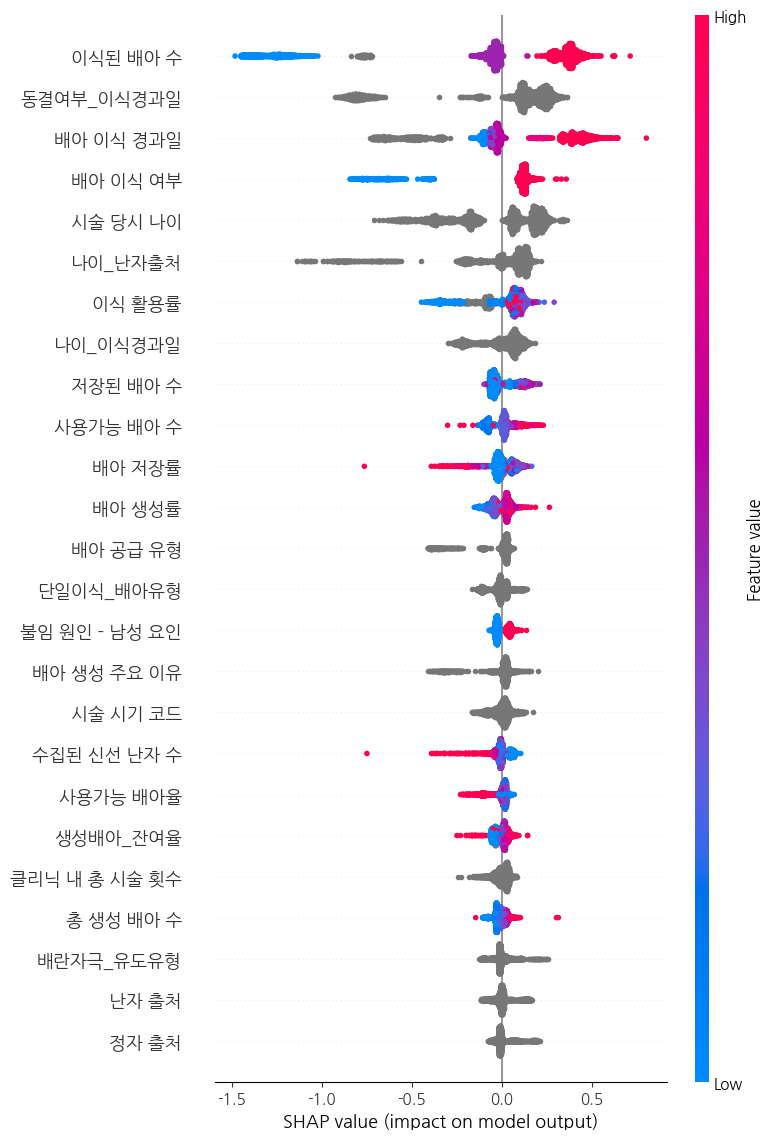

In [ ]:
import shap
X_cb_shap, _, cat_idx_shap = prepare_catboost_data(fe_train[BEST_COLS])
shap_model = CatBoostClassifier(
    **BEST_CB_PARAMS, iterations=4000, loss_function="Logloss", eval_metric="AUC",
    random_seed=RANDOM_STATE, verbose=False, allow_writing_files=False
)
shap_model.fit(X_cb_shap, y, cat_features=cat_idx_shap, verbose=False)
X_shap = X_cb_shap.sample(min(3000, len(X_cb_shap)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap)
shap_to_plot = shap_values[-1] if isinstance(shap_values, list) else shap_values
shap.summary_plot(shap_to_plot, X_shap, max_display=25)


## 결과를 읽는 순서

1. 피처 세트 표에서 최고 OOF AUC와 Fold 표준편차를 확인합니다.
2. 모델별 OOF AUC와 fold별 흔들림을 비교합니다.
3. 단일 모델보다 앙상블 AUC가 실제로 높은지 확인합니다.
4. Spearman/범주별 성공률은 관계 탐색에, SHAP은 최종 모델의 예측 방향 해석에 사용합니다.
5. 최종 제출은 `/content/final_submission_high_performance.csv` 한 개만 사용합니다.
